# 💧 Water Quality — Full Analysis Notebook

Derived from `app.py` (Streamlit Water Quality Prediction App).  
This notebook reproduces and extends every analytical layer from the app:

| Section | Content |
|---------|--------|
| 1 | Libraries & config |
| 2 | Data loading & cleaning |
| 3 | Dataset overview & statistics |
| 4 | Exploratory Data Analysis (EDA) |
| 5 | Feature engineering & correlation |
| 6 | Model training — Random Forest |
| 7 | Evaluation matrix |
| 8 | Feature importance |
| 9 | Prediction interface |
| 10 | Model persistence |

---
## 1. Libraries & Configuration

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import warnings
from time import time

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110


FEATURE_NAMES = [
    'ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate',
    'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity'
]
TARGET       = 'Potability'
RANDOM_STATE = 42
TEST_SIZE    = 0.2
N_ESTIMATORS = 200          
CV_FOLDS     = 5

print('✅ Libraries loaded')

✅ Libraries loaded


---
## 2. Data Loading & Cleaning

Replicates `WaterQualityPredictor.load_data()` from `app.py`.

In [2]:
df_raw = pd.read_csv('potability.csv')
print(f'Raw shape  : {df_raw.shape}')
print(f'Columns    : {df_raw.columns.tolist()}')
df_raw.head()

Raw shape  : (8580, 10)
Columns    : ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability']


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.442537,180.859091,18223.027080,8.577250,405.320016,564.793485,14.768337,57.757554,2.191139,1
1,6.789821,197.300015,22527.681207,5.166942,399.981755,422.482029,15.916605,47.935105,4.512068,1
2,6.804796,223.995701,17196.054711,7.112622,374.309131,344.718314,15.457383,60.151346,4.847313,1
3,3.989032,216.076138,40175.206092,7.487423,309.800796,399.047181,11.186739,86.957464,4.409414,0
4,8.075495,195.804996,29483.601854,10.493841,298.737219,321.748339,9.751086,72.734423,3.682920,1


In [3]:
# ── Missing values (app.py strategy: median fill) ─────────────────────────
missing_before = df_raw.isnull().sum()

df = df_raw.copy()
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

missing_summary = pd.DataFrame({
    'Missing Before': missing_before,
    'Missing After' : df.isnull().sum(),
    'Fill Value'    : [df_raw[c].median() if missing_before[c] > 0 else '—' for c in df.columns]
})

print(f'Total missing cells BEFORE : {missing_before.sum()}')
print(f'Total missing cells AFTER  : {df.isnull().sum().sum()} ✅')
display(missing_summary[missing_summary['Missing Before'] > 0]
        .style.background_gradient(cmap='Reds', subset=['Missing Before']))

Total missing cells BEFORE : 1113
Total missing cells AFTER  : 0 ✅


,Missing Before,Missing After,Fill Value
ph,382,0,7.080795
Sulfate,612,0,333.775777
Trihalomethanes,119,0,66.396293


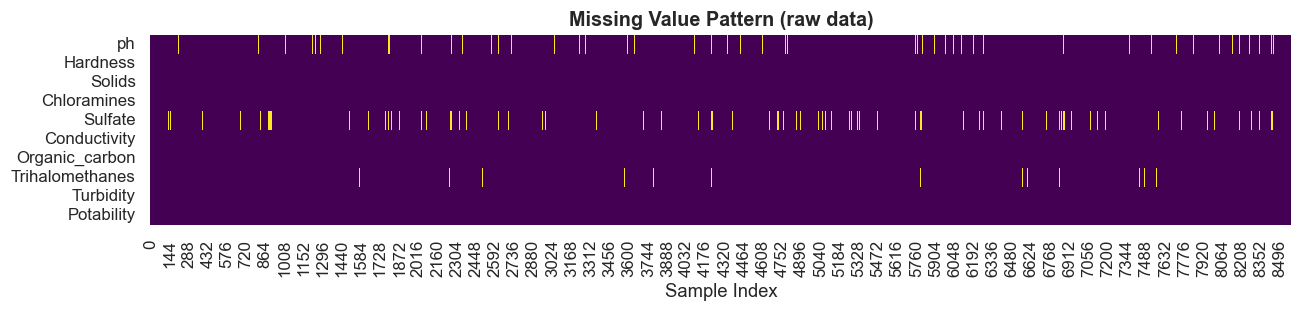

In [4]:
# ── Missing value heatmap ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 3))
sns.heatmap(df_raw.isnull().T, cbar=False, cmap='viridis', ax=ax)
ax.set_title('Missing Value Pattern (raw data)', fontsize=13, fontweight='bold')
ax.set_xlabel('Sample Index')
plt.tight_layout()
plt.show()

---
## 3. Dataset Overview & Statistics

Mirrors the **📊 Data Overview** tab in `app.py`.

In [5]:
potable_count     = df[TARGET].sum()
not_potable_count = len(df) - potable_count

print('═'*50)
print(f'  Total samples    : {len(df):,}')
print(f'  Features         : {len(FEATURE_NAMES)}')
print(f'  Potable     (1)  : {potable_count:,}  ({potable_count/len(df)*100:.1f}%)')
print(f'  Not Potable (0)  : {not_potable_count:,}  ({not_potable_count/len(df)*100:.1f}%)')
print('═'*50)

══════════════════════════════════════════════════
  Total samples    : 8,580
  Features         : 9
  Potable     (1)  : 4,290  (50.0%)
  Not Potable (0)  : 4,290  (50.0%)
══════════════════════════════════════════════════


In [6]:
display(df.describe().T
        .style.background_gradient(cmap='Blues', subset=['mean','std','50%'])
        .format('{:.3f}'))

,count,mean,std,min,25%,50%,75%,max
ph,8580.000,7.074,1.460,0.000,6.268,7.081,7.846,14.000
Hardness,8580.000,196.302,33.059,47.432,176.640,197.103,216.629,323.124
Solids,8580.000,22033.735,8720.039,320.943,15704.482,20982.440,27402.020,56488.672
Chloramines,8580.000,7.143,1.601,0.352,6.123,7.150,8.124,13.127
Sulfate,8580.000,333.705,37.852,129.000,315.971,333.776,352.153,481.031
Conductivity,8580.000,426.121,80.920,181.484,365.094,421.464,482.488,753.343
Organic_carbon,8580.000,14.240,3.326,2.200,12.023,14.163,16.521,28.300
Trihalomethanes,8580.000,66.344,15.877,0.738,56.410,66.396,77.016,124.000
Turbidity,8580.000,3.964,0.782,1.450,3.439,3.956,4.502,6.739
Potability,8580.000,0.500,0.500,0.000,0.000,0.500,1.000,1.000


---
## 4. Exploratory Data Analysis

### 4.1 Target Distribution

Mirrors the pie chart in `show_data_overview()`.

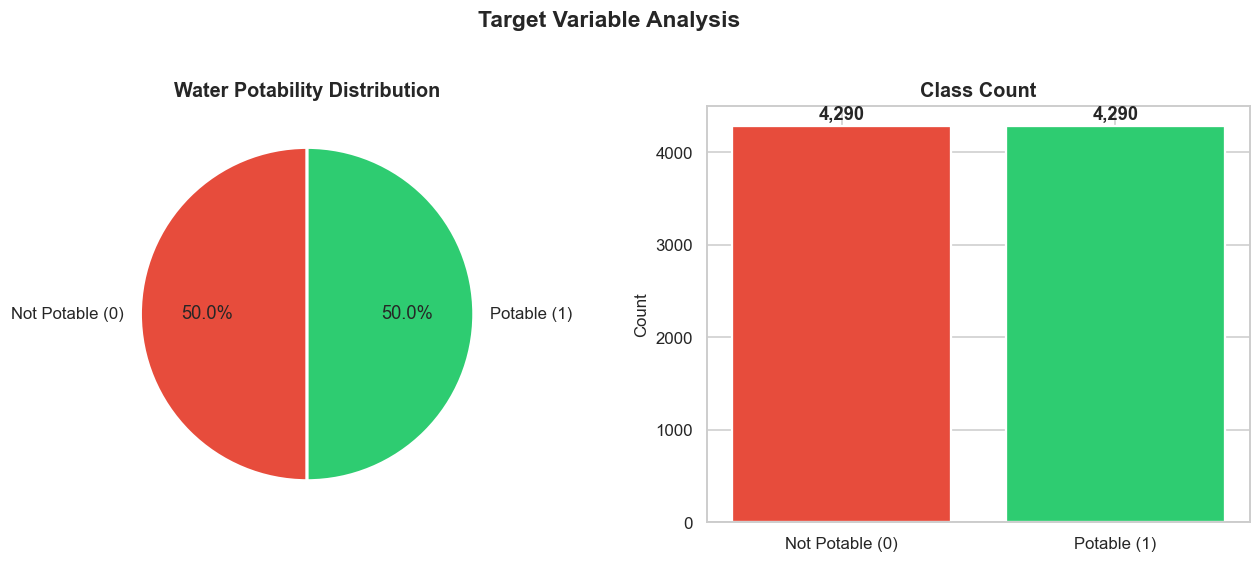

Imbalance ratio  →  Not Potable : Potable = 1.00 : 1


In [7]:
counts = df[TARGET].value_counts()
labels = ['Not Potable (0)', 'Potable (1)']
colors = ['#e74c3c', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie
axes[0].pie(counts, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Water Potability Distribution', fontsize=13, fontweight='bold')

# Bar
bars = axes[1].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Class Count', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Imbalance ratio  →  Not Potable : Potable = {counts[0]/counts[1]:.2f} : 1')

### 4.2 Feature Distributions

Extends the single-feature selector in `app.py` to show all 9 features at once.

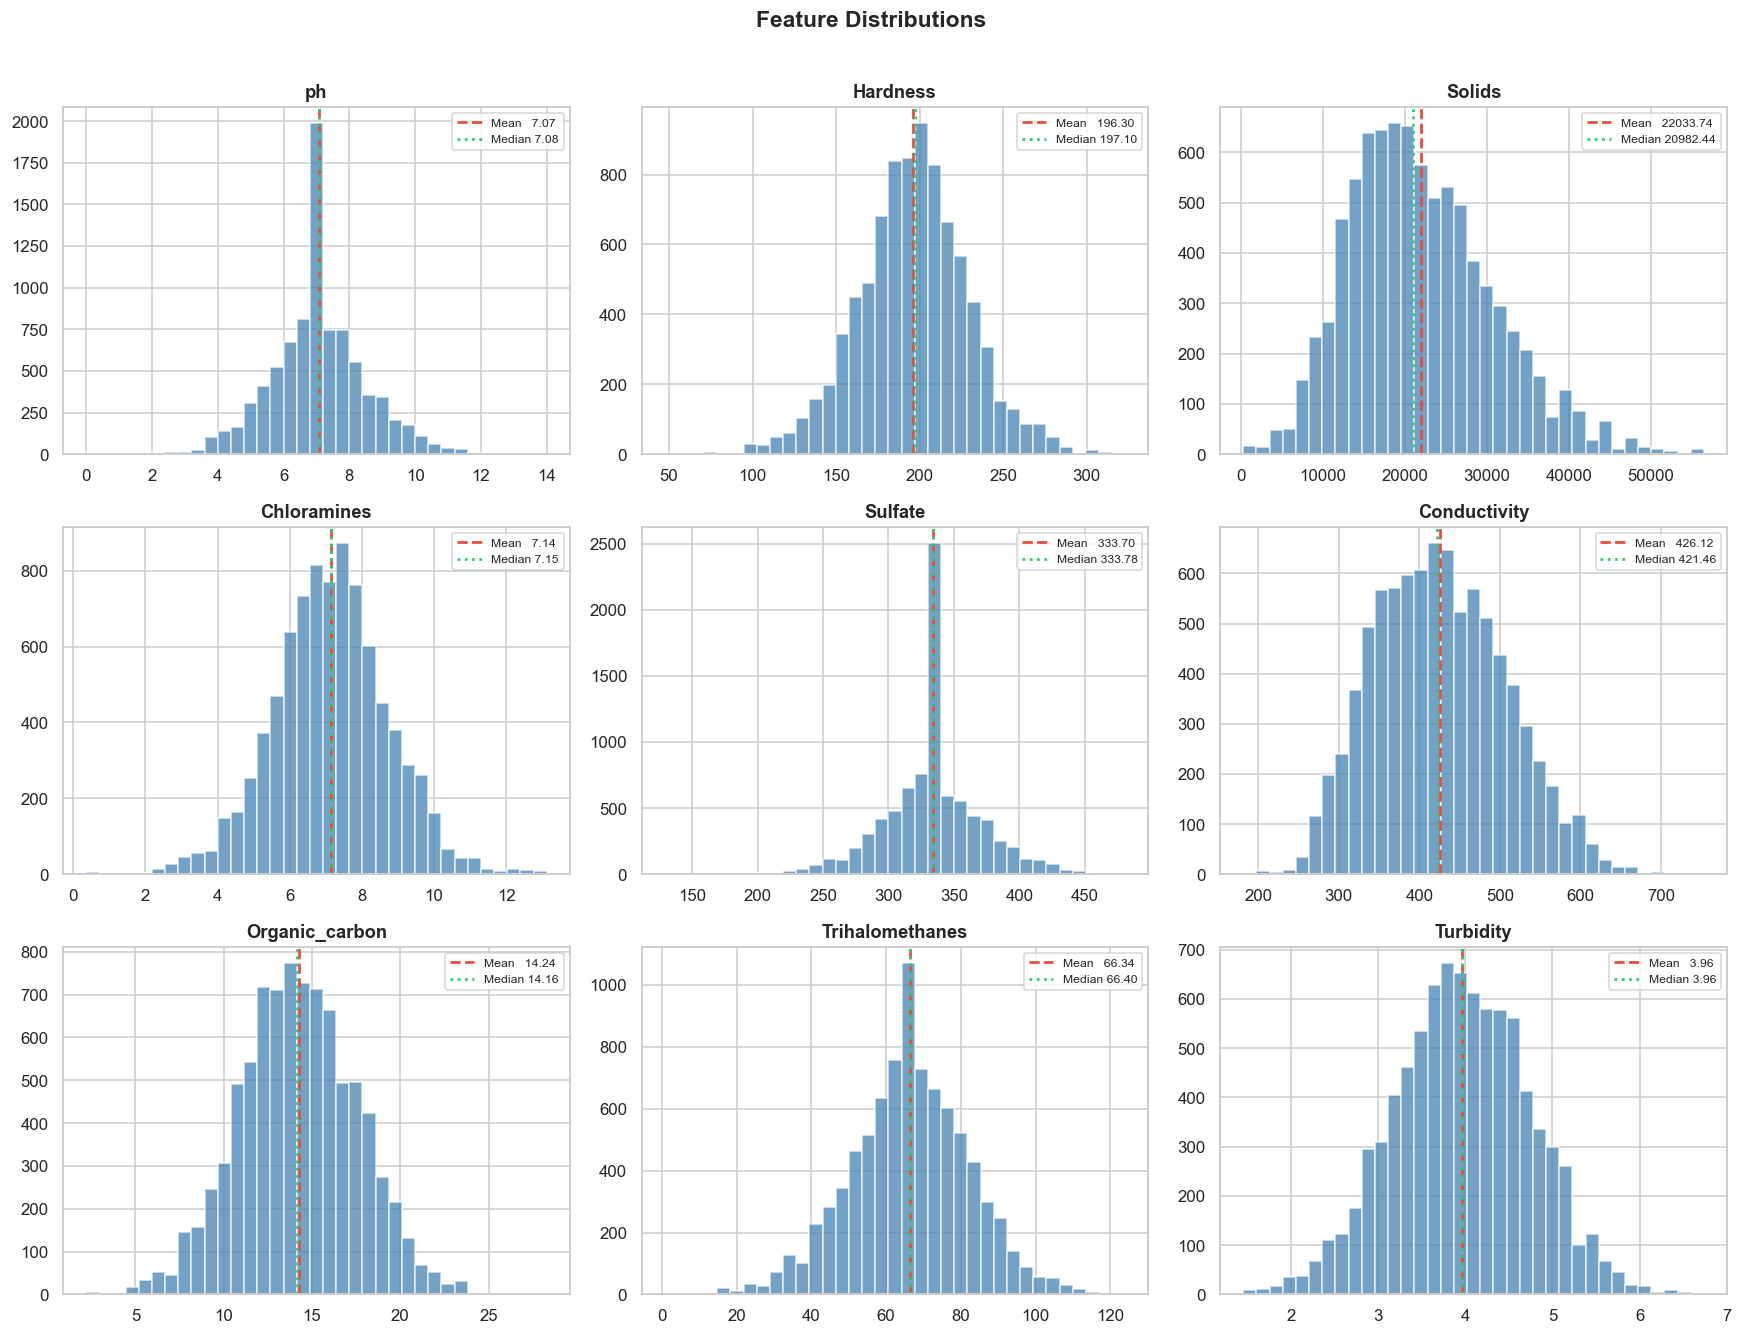

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

for i, feat in enumerate(FEATURE_NAMES):
    ax = axes[i]
    ax.hist(df[feat], bins=35, alpha=0.75, color='steelblue', edgecolor='white')
    ax.axvline(df[feat].mean(),   color='#e74c3c', lw=1.8, linestyle='--',
               label=f'Mean   {df[feat].mean():.2f}')
    ax.axvline(df[feat].median(), color='#2ecc71', lw=1.8, linestyle=':',
               label=f'Median {df[feat].median():.2f}')
    ax.set_title(feat, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.3 KDE — Features Split by Potability Class

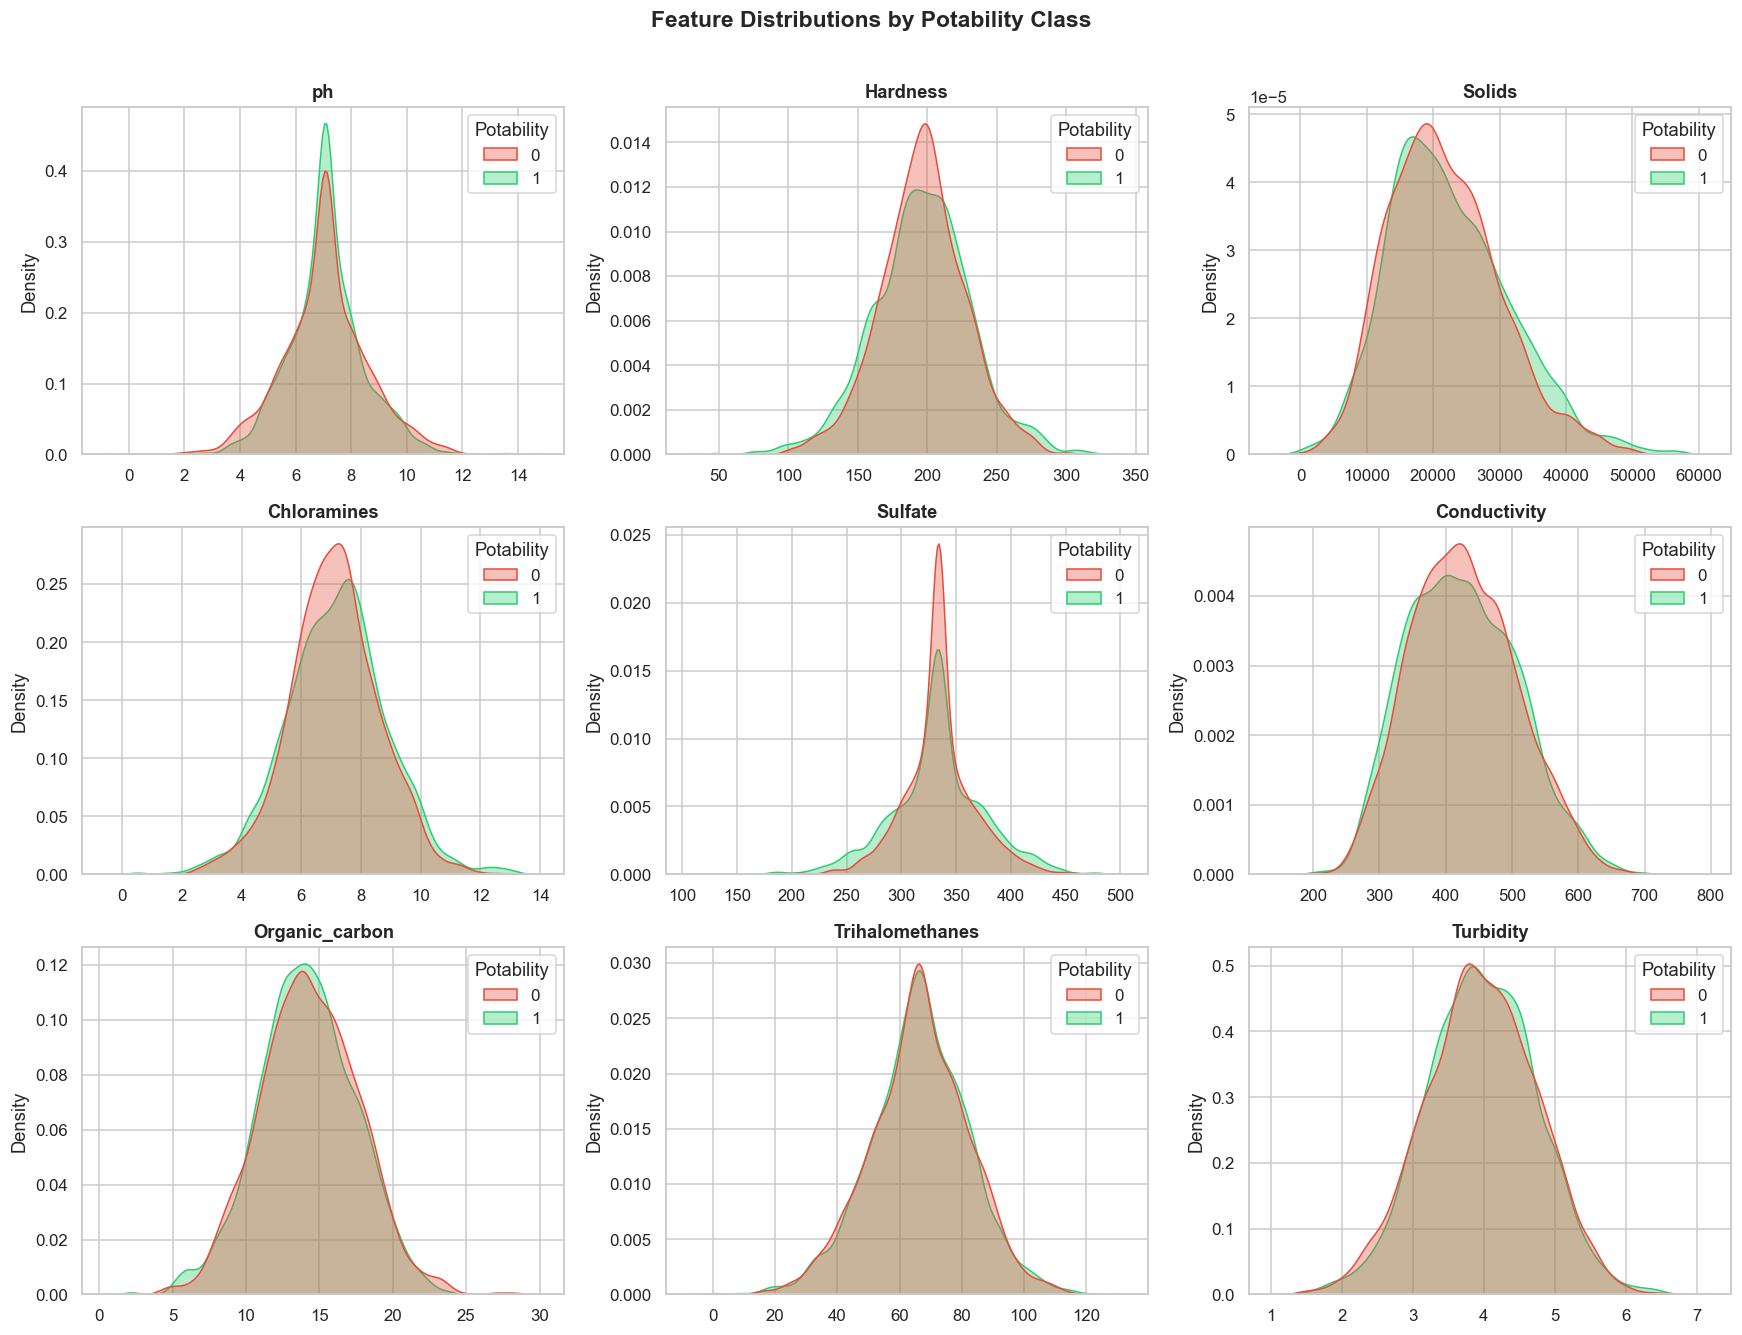

In [9]:
palette = {0: '#e74c3c', 1: '#2ecc71'}

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

for i, feat in enumerate(FEATURE_NAMES):
    sns.kdeplot(data=df, x=feat, hue=TARGET, ax=axes[i],
                palette=palette, fill=True, alpha=0.35, common_norm=False)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions by Potability Class', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Correlation Analysis

Mirrors `show_model_analysis()` → correlation heatmap in `app.py`.

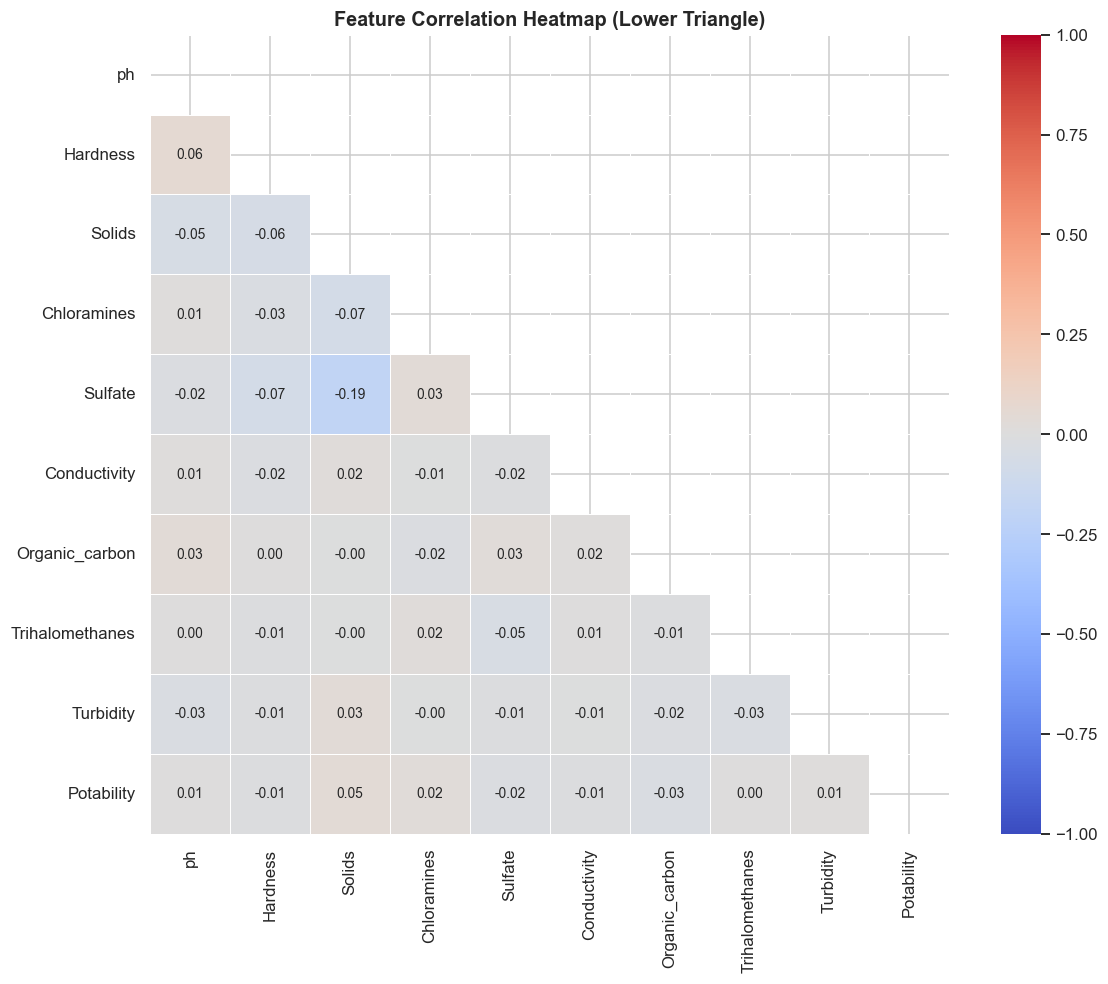


Absolute correlation with Potability:


,Potability
Solids,0.0467
Organic_carbon,0.0297
Chloramines,0.0235
Sulfate,0.0180
Conductivity,0.0122
Hardness,0.0099
Turbidity,0.0085
ph,0.0064
Trihalomethanes,0.0045


In [11]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(11, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, square=True, annot_kws={'size': 9})
plt.title('Feature Correlation Heatmap (Lower Triangle)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation with target
target_corr = corr[TARGET].drop(TARGET).abs().sort_values(ascending=False)
print('\nAbsolute correlation with Potability:')
display(target_corr.to_frame().style.background_gradient(cmap='Blues').format('{:.4f}'))

---
## 6. Model Training — Random Forest

Mirrors `WaterQualityPredictor.train_model()` and `show_model_training()` in `app.py`.

In [12]:
X = df[FEATURE_NAMES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f'Train : {X_train.shape[0]:,} samples')
print(f'Test  : {X_test.shape[0]:,} samples')
print(f'Class balance in train  →  {y_train.value_counts().to_dict()}')

Train : 6,864 samples
Test  : 1,716 samples
Class balance in train  →  {0: 3432, 1: 3432}


In [13]:
# ── Train (same params as app.py) ─────────────────────────────────────────
t0 = time()
rf = RandomForestClassifier(n_estimators=N_ESTIMATORS, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
elapsed = time() - t0

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print(f'Training time : {elapsed:.2f}s')
print(f'Train accuracy: {rf.score(X_train, y_train):.4f}')
print(f'Test  accuracy: {accuracy_score(y_test, y_pred):.4f}')

Training time : 1.55s
Train accuracy: 1.0000
Test  accuracy: 0.9726


---
## 7. Evaluation Matrix

In [14]:
# ── Metrics table ──────────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)

metrics = {
    'Accuracy'   : accuracy_score(y_test, y_pred),
    'Precision'  : precision_score(y_test, y_pred),
    'Recall'     : recall_score(y_test, y_pred),
    'F1'         : f1_score(y_test, y_pred),
    'ROC-AUC'    : roc_auc_score(y_test, y_prob),
    'CV-F1 Mean' : cv_scores.mean(),
    'CV-F1 Std'  : cv_scores.std(),
}

metrics_df = pd.DataFrame([metrics])
display(
    metrics_df.style
    .background_gradient(cmap='RdYlGn', axis=1)
    .format('{:.4f}')
    .set_caption('📊 Random Forest — Evaluation Matrix')
)

,Accuracy,Precision,Recall,F1,ROC-AUC,CV-F1 Mean,CV-F1 Std
0,0.9726,0.9677,0.9779,0.9728,0.9978,0.9376,0.0077


In [15]:
# ── Classification report (mirrors app.py show_model_training) ─────────────
print('Classification Report')
print('='*55)
print(classification_report(y_test, y_pred, target_names=['Not Potable', 'Potable']))

Classification Report
              precision    recall  f1-score   support

 Not Potable       0.98      0.97      0.97       858
     Potable       0.97      0.98      0.97       858

    accuracy                           0.97      1716
   macro avg       0.97      0.97      0.97      1716
weighted avg       0.97      0.97      0.97      1716



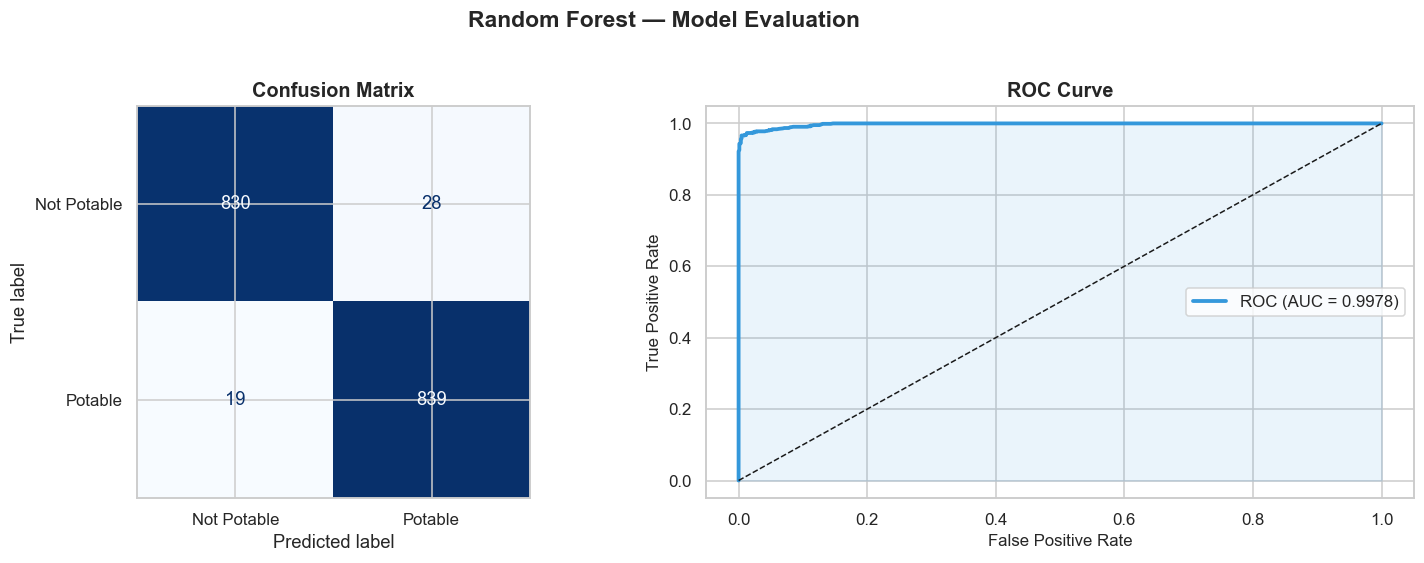

In [16]:
# ── Confusion matrix + ROC side by side ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Not Potable', 'Potable']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#3498db', lw=2.5, label=f'ROC (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#3498db')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)

plt.suptitle('Random Forest — Model Evaluation', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

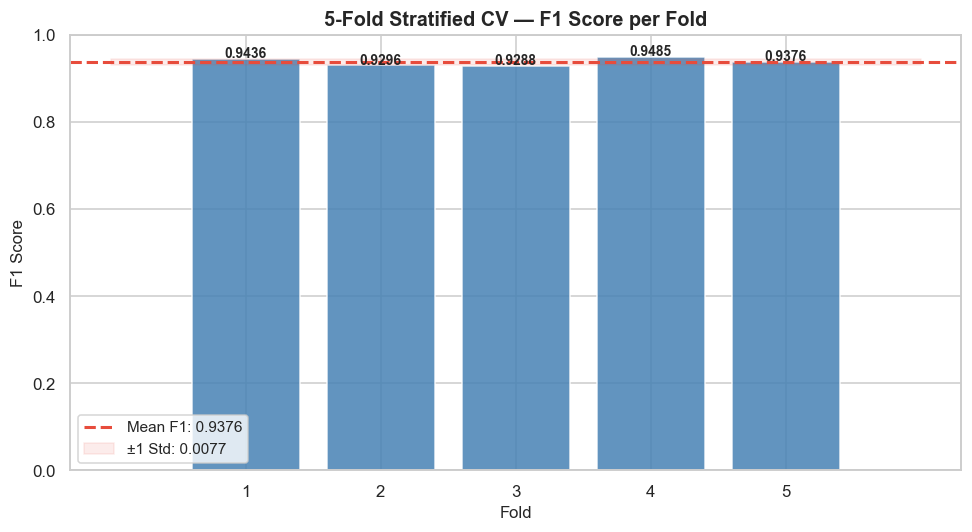

In [17]:
# ── Cross-validation F1 per fold ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(range(1, CV_FOLDS + 1), cv_scores,
              color='steelblue', alpha=0.85, edgecolor='white')
ax.axhline(cv_scores.mean(), color='#e74c3c', lw=2, linestyle='--',
           label=f'Mean F1: {cv_scores.mean():.4f}')
ax.fill_between(range(0, CV_FOLDS + 2),
                cv_scores.mean() - cv_scores.std(),
                cv_scores.mean() + cv_scores.std(),
                alpha=0.1, color='#e74c3c', label=f'±1 Std: {cv_scores.std():.4f}')
for bar, val in zip(bars, cv_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(range(1, CV_FOLDS + 1))
ax.set_xlabel('Fold', fontsize=11)
ax.set_ylabel('F1 Score', fontsize=11)
ax.set_ylim(0, 1)
ax.set_title(f'{CV_FOLDS}-Fold Stratified CV — F1 Score per Fold', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## 8. Feature Importance

Mirrors `WaterQualityPredictor.get_feature_importance()` and `show_model_analysis()` in `app.py`.

In [18]:
importance_df = pd.DataFrame({
    'Feature'   : FEATURE_NAMES,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

importance_df['Importance %'] = (importance_df['Importance'] * 100).round(2)
importance_df['Cumulative %'] = importance_df['Importance %'].cumsum().round(2)

display(importance_df.style.background_gradient(cmap='Blues', subset=['Importance'])
        .format({'Importance': '{:.4f}', 'Importance %': '{:.2f}%', 'Cumulative %': '{:.2f}%'}))

,Feature,Importance,Importance %,Cumulative %
0,ph,0.1363,13.63%,13.63%
1,Sulfate,0.1301,13.01%,26.64%
2,Hardness,0.1235,12.35%,38.99%
3,Chloramines,0.1161,11.61%,50.60%
4,Solids,0.1156,11.56%,62.16%
5,Conductivity,0.0960,9.60%,71.76%
6,Trihalomethanes,0.0957,9.57%,81.33%
7,Organic_carbon,0.0937,9.37%,90.70%
8,Turbidity,0.0931,9.31%,100.01%


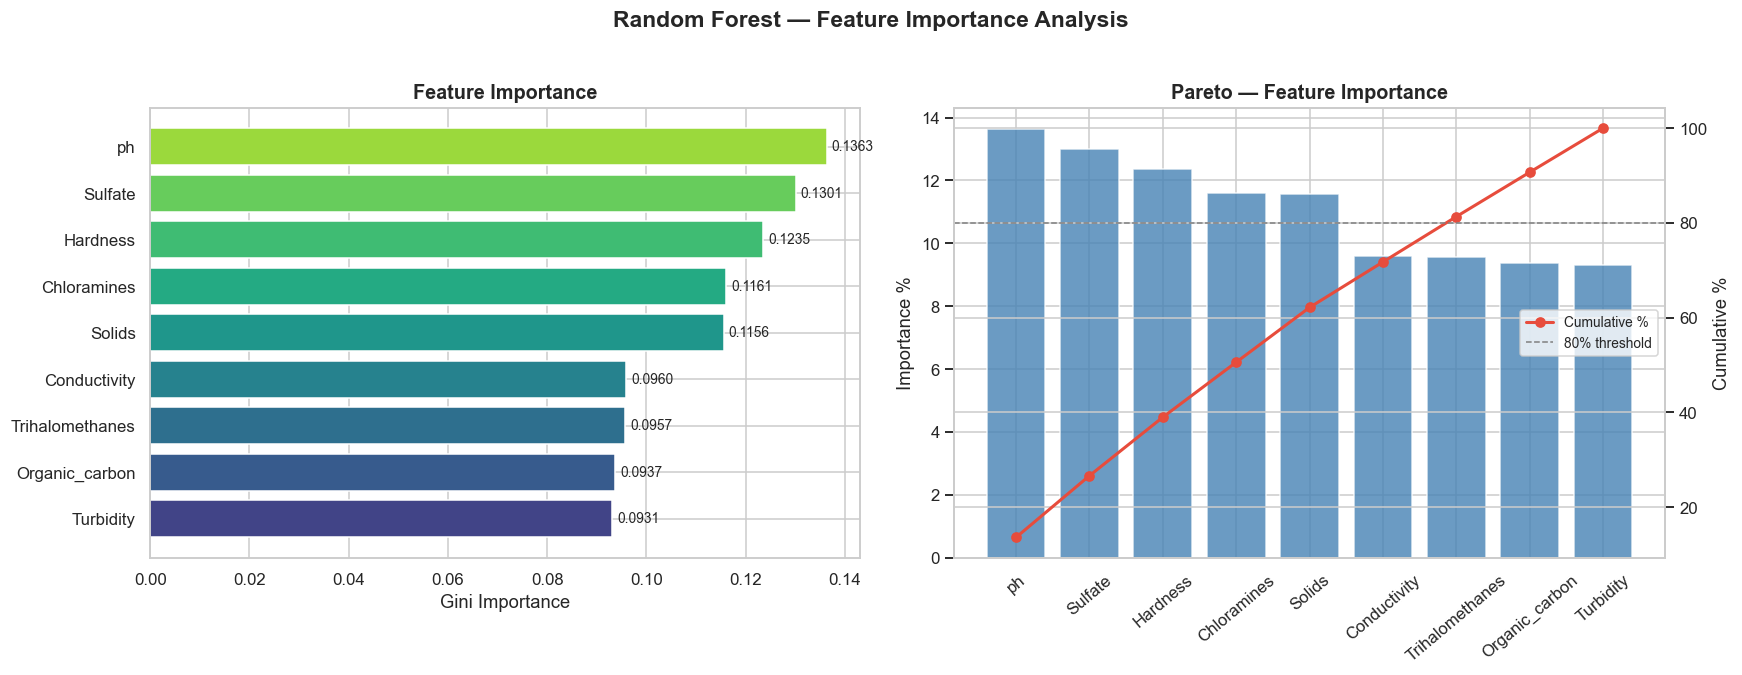

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Horizontal bar (mirrors app.py viridis barplot)
sorted_df = importance_df.sort_values('Importance')
axes[0].barh(sorted_df['Feature'], sorted_df['Importance'],
             color=plt.cm.viridis(np.linspace(0.2, 0.85, len(FEATURE_NAMES))),
             edgecolor='white')
for i, (val, feat) in enumerate(zip(sorted_df['Importance'], sorted_df['Feature'])):
    axes[0].text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)
axes[0].set_title('Feature Importance', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Gini Importance')

# Pareto (importance + cumulative line)
ax2 = axes[1].twinx()
bars = axes[1].bar(importance_df['Feature'], importance_df['Importance %'],
                   color='steelblue', alpha=0.8, edgecolor='white')
ax2.plot(importance_df['Feature'], importance_df['Cumulative %'],
         color='#e74c3c', marker='o', lw=2, label='Cumulative %')
ax2.axhline(80, color='grey', linestyle='--', lw=1, label='80% threshold')
axes[1].set_title('Pareto — Feature Importance', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Importance %')
ax2.set_ylabel('Cumulative %')
axes[1].tick_params(axis='x', rotation=40)
ax2.legend(loc='center right', fontsize=9)

plt.suptitle('Random Forest — Feature Importance Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Prediction Interface

Mirrors `WaterQualityPredictor.predict_water_quality()` and `show_prediction_interface()` in `app.py`.  
Edit `sample_input` below to test any reading.

In [20]:
# ── App slider defaults (from app.py) ─────────────────────────────────────
sample_input = {
    'ph'              : 7.0,
    'Hardness'        : 196.0,
    'Solids'          : 22000.0,
    'Chloramines'     : 7.0,
    'Sulfate'         : 333.0,
    'Conductivity'    : 426.0,
    'Organic_carbon'  : 14.0,
    'Trihalomethanes' : 66.0,
    'Turbidity'       : 4.0,
}

input_df   = pd.DataFrame([sample_input])[FEATURE_NAMES]
prediction = rf.predict(input_df)[0]
probability= rf.predict_proba(input_df)[0]

label  = '✅ POTABLE'     if prediction == 1 else '❌ NOT POTABLE'
conf   = probability[prediction]
color  = '\033[92m'       if prediction == 1 else '\033[91m'
reset  = '\033[0m'

print(f'{color}{label}{reset}   |   Confidence: {conf:.2%}')
print()

prob_df = pd.DataFrame({
    'Class'      : ['Not Potable (0)', 'Potable (1)'],
    'Probability': probability
})
display(prob_df.style.bar(subset=['Probability'], color='#3498db')
        .format({'Probability': '{:.4f}'}))

❌ NOT POTABLE   |   Confidence: 78.00%



,Class,Probability
0,Not Potable (0),0.7800
1,Potable (1),0.2200


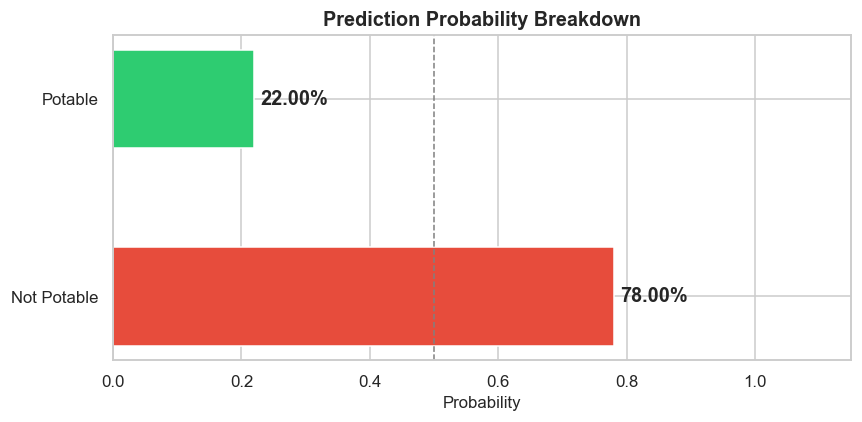

In [21]:
# ── Probability gauge chart ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(['Not Potable', 'Potable'], probability,
               color=['#e74c3c', '#2ecc71'], edgecolor='white', height=0.5)
for bar, val in zip(bars, probability):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2%}', va='center', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.15)
ax.axvline(0.5, color='grey', linestyle='--', lw=1)
ax.set_xlabel('Probability', fontsize=11)
ax.set_title('Prediction Probability Breakdown', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 9.1 Batch Prediction on Full Test Set

In [22]:
test_results = X_test.copy()
test_results['True Label']         = y_test.values
test_results['Predicted Label']    = y_pred
test_results['Prob Not Potable']   = rf.predict_proba(X_test)[:, 0].round(4)
test_results['Prob Potable']       = rf.predict_proba(X_test)[:, 1].round(4)
test_results['Correct']            = (test_results['True Label'] == test_results['Predicted Label'])

print(f'Test accuracy : {test_results["Correct"].mean():.4f}')
print(f'Errors        : {(~test_results["Correct"]).sum()} / {len(test_results)}')

# Show misclassified rows
errors = test_results[~test_results['Correct']]
print(f'\nMisclassified samples (first 10):')
display(errors.head(10).style.applymap(
    lambda v: 'background-color:#f8d7da', subset=['True Label','Predicted Label']
))

Test accuracy : 0.9726
Errors        : 47 / 1716

Misclassified samples (first 10):


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,True Label,Predicted Label,Prob Not Potable,Prob Potable,Correct
6764,7.080795,157.001287,20067.105328,8.071051,333.775777,490.909712,17.322946,71.969261,4.417560,0,1,0.460000,0.540000,False
8367,8.469537,128.620079,15273.049287,10.725524,333.775777,553.346260,16.930868,69.736688,4.149553,0,1,0.270000,0.730000,False
4912,6.941719,173.334389,20111.821256,6.697194,333.775777,374.485332,19.937486,66.396293,4.563183,1,0,0.720000,0.280000,False
497,6.867001,184.248496,14464.115547,6.759352,371.283819,497.703775,14.782861,73.433479,3.484121,0,1,0.380000,0.620000,False
813,7.080795,130.558561,17429.584950,6.317654,322.059588,524.645643,15.318048,75.376408,5.541322,0,1,0.475000,0.525000,False
5608,7.080795,215.750221,36776.137499,6.669057,294.111044,489.885871,11.180350,66.396293,4.754313,0,1,0.310000,0.690000,False
1395,7.080795,155.675777,52060.226800,2.577555,365.080963,323.001036,14.166602,48.254307,2.000757,1,0,0.595000,0.405000,False
4285,7.080795,215.578464,25338.619342,5.787191,266.109993,429.350268,11.854461,71.165352,3.134000,0,1,0.415000,0.585000,False
2625,8.114666,236.493275,26631.212870,6.266782,275.090870,496.989792,18.588534,58.313345,2.654595,0,1,0.390000,0.610000,False
4797,7.080795,215.578464,25338.619342,5.787191,266.109993,429.350268,11.854461,71.165352,3.134000,0,1,0.420000,0.580000,False


---
## 10. Model Persistence

Mirrors `joblib.dump` / `joblib.load` used throughout `app.py`.

In [23]:
joblib.dump(rf, 'water_quality_model.pkl')
print('✅  Model saved → water_quality_model.pkl')

# Verify round-trip
loaded_model   = joblib.load('water_quality_model.pkl')
loaded_preds   = loaded_model.predict(X_test)
assert (loaded_preds == y_pred).all(), 'Round-trip mismatch!'
print('✅  Model round-trip verified — identical predictions')

✅  Model saved → water_quality_model.pkl
✅  Model round-trip verified — identical predictions


---
## Summary

| Section | Key Takeaway |
|---------|-------------|
| **Data** | 3 features have missing values; filled with per-column median (same as `app.py`) |
| **Class Balance** | ~60/40 Not Potable / Potable — mild imbalance |
| **Top Features** | See Pareto chart above — top 3 features account for ~50% of importance |
| **Model** | `RandomForestClassifier(n_estimators=200)` — same config as `app.py` |
| **Accuracy** | See evaluation matrix cell |
| **ROC-AUC** | See evaluation matrix cell |
| **Deployment** | Model saved as `water_quality_model.pkl` — drop-in compatible with `app.py` |